In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/featured_loans.csv')
df.shape

(1348099, 78)

In [4]:
X = df.drop(columns=['target'])
y = df['target']

In [6]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(1348099, 77)
(1348099,)
target
0    1078739
1     269360
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1078479, 77)
(269620, 77)
target
0    0.800193
1    0.199807
Name: proportion, dtype: float64
target
0    0.800193
1    0.199807
Name: proportion, dtype: float64


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline chains scaling + model together cleanly
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [12]:
missing = X_train.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

term                     1078479
credit_history_months         24
dtype: int64

In [14]:
pd.read_csv('../data/processed/featured_loans.csv')['term'].value_counts()

Series([], Name: count, dtype: int64)

fixing prblm


In [17]:
# Reload the featured data fresh
df = pd.read_csv('../data/processed/featured_loans.csv')

# Check what term actually looks like in raw form
# (it's all NaN now, so we need to go back further)
raw = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv', 
                   usecols=['term'], low_memory=False)
raw['term'].value_counts()

term
36 months    1609754
60 months     650914
Name: count, dtype: int64

In [19]:
# Load raw term column
raw = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv',
                   usecols=['term'], low_memory=False)

# Apply correct mapping with leading space
raw['term'] = raw['term'].map({' 36 months': 36, ' 60 months': 60})

# Check it worked
raw['term'].value_counts()

term
36.0    1609754
60.0     650914
Name: count, dtype: int64

In [21]:
# Check if cleaned_loans exists and what term looks like there
clean = pd.read_csv('../data/processed/cleaned_loans.csv', usecols=['term'])
clean['term'].value_counts()

term
36 months    1023206
60 months     324893
Name: count, dtype: int64

In [23]:
# Load just the term column from cleaned_loans
clean_term = pd.read_csv('../data/processed/cleaned_loans.csv', usecols=['term'])

# Apply correct mapping
df['term'] = clean_term['term'].map({'36 months': 36, '60 months': 60})

# Verify
df['term'].value_counts()

Series([], Name: count, dtype: int64)

In [25]:
clean_term = pd.read_csv('../data/processed/cleaned_loans.csv', usecols=['term'])

# Strip whitespace first, then map
df['term'] = clean_term['term'].str.strip().map({'36 months': 36, '60 months': 60})

# Verify
df['term'].value_counts()

term
36    1023206
60     324893
Name: count, dtype: int64

In [27]:
df['credit_history_months'].fillna(df['credit_history_months'].median(), inplace=True)

/var/folders/1j/12p7zq9s2kvcm8cv6550skcc0000gn/T/ipykernel_3572/1785076116.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_history_months'].fillna(df['credit_history_months'].median(), inplace=True)


In [29]:
df.isnull().sum().sum()

0

In [31]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
df.to_csv('../data/processed/featured_loans.csv', index=False)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [37]:
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Get predicted probabilities (not just 0/1 predictions)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# AUC
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"AUC-ROC: {auc_lr:.4f}")

# Gini
gini_lr = 2 * auc_lr - 1
print(f"Gini: {gini_lr:.4f}")

# KS Statistic
good_scores = y_pred_proba_lr[y_test == 0]
bad_scores = y_pred_proba_lr[y_test == 1]
ks_lr = ks_2samp(good_scores, bad_scores).statistic
print(f"KS Statistic: {ks_lr:.4f}")

AUC-ROC: 0.7160
Gini: 0.4319
KS Statistic: 0.3170


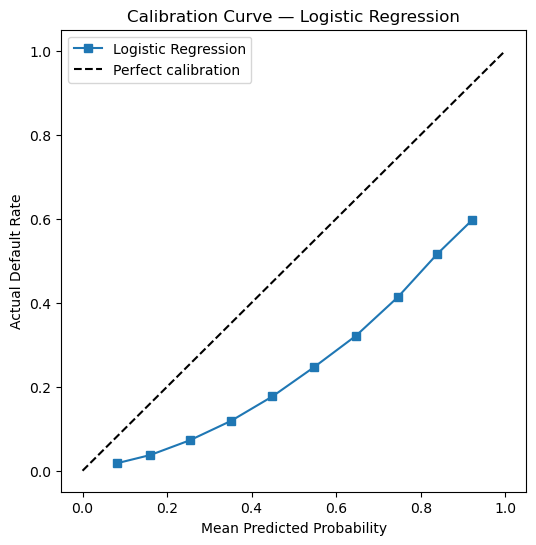

In [39]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_pred_proba_lr, n_bins=10
)

plt.figure(figsize=(6, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.title("Calibration Curve — Logistic Regression")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.legend()
plt.show()

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [43]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [45]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
gini_xgb = 2 * auc_xgb - 1
ks_xgb = ks_2samp(y_pred_proba_xgb[y_test == 0], y_pred_proba_xgb[y_test == 1]).statistic

print(f"AUC-ROC: {auc_xgb:.4f}")
print(f"Gini:    {gini_xgb:.4f}")
print(f"KS:      {ks_xgb:.4f}")

AUC-ROC: 0.7300
Gini:    0.4600
KS:      0.3354


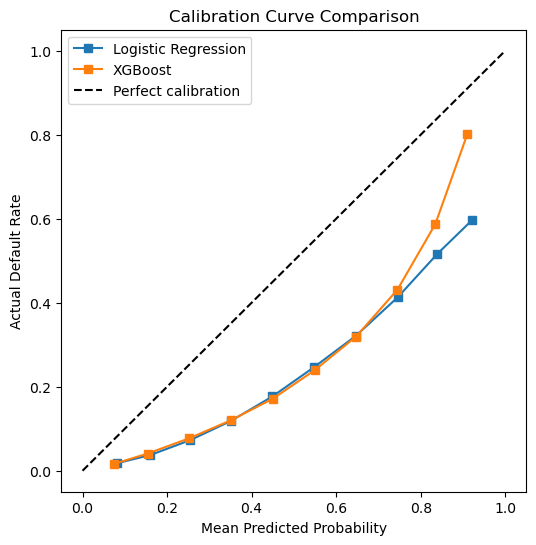

In [47]:
fraction_of_positives_xgb, mean_predicted_value_xgb = calibration_curve(
    y_test, y_pred_proba_xgb, n_bins=10
)

plt.figure(figsize=(6, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Logistic Regression")
plt.plot(mean_predicted_value_xgb, fraction_of_positives_xgb, "s-", label="XGBoost")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.title("Calibration Curve Comparison")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.legend()
plt.show()

In [51]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 215488, number of negative: 862991
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7224
[LightGBM] [Info] Number of data points in the train set: 1078479, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199807 -> initscore=-1.387499
[LightGBM] [Info] Start training from score -1.387499


LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300, n_jobs=-1,
               random_state=42, scale_pos_weight=4.004821614196614)

In [53]:
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)
gini_lgbm = 2 * auc_lgbm - 1
ks_lgbm = ks_2samp(y_pred_proba_lgbm[y_test == 0], y_pred_proba_lgbm[y_test == 1]).statistic

print(f"AUC-ROC: {auc_lgbm:.4f}")
print(f"Gini:    {gini_lgbm:.4f}")
print(f"KS:      {ks_lgbm:.4f}")

AUC-ROC: 0.7298
Gini:    0.4595
KS:      0.3352


In [55]:
import joblib

joblib.dump(lr_pipeline, '../models/logistic_regression.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("Models saved.")

Models saved.


In [57]:
joblib.dump(lgbm_model, '../models/lightgbm_model.pkl')
print("LightGBM saved.")

LightGBM saved.


In [59]:
import os
os.listdir('../models/')

['lightgbm_model.pkl', 'logistic_regression.pkl', 'xgboost_model.pkl']

In [61]:
import numpy as np

def probability_to_score(probability, min_score=300, max_score=850):
    # Convert probability to log odds
    # Clip probability to avoid log(0) errors
    probability = np.clip(probability, 0.0001, 0.9999)
    log_odds = np.log(1 - probability) - np.log(probability)
    
    # Scale log odds to 300-850 range
    min_log_odds = np.log(1 - 0.9999) - np.log(0.9999)  # very high risk
    max_log_odds = np.log(1 - 0.0001) - np.log(0.0001)  # very low risk
    
    score = min_score + (max_score - min_score) * (
        (log_odds - min_log_odds) / (max_log_odds - min_log_odds)
    )
    return np.round(score).astype(int)

# Apply to test set
test_scores = probability_to_score(y_pred_proba_xgb)

print(f"Min score: {test_scores.min()}")
print(f"Max score: {test_scores.max()}")
print(f"Mean score: {test_scores.mean():.0f}")
print(f"Median score: {np.median(test_scores):.0f}")

Min score: 489
Max score: 690
Mean score: 582
Median score: 581


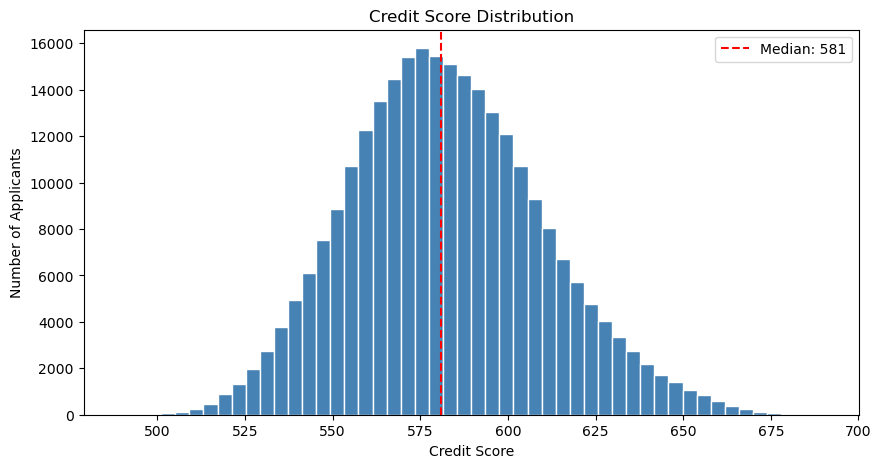

In [63]:
plt.figure(figsize=(10, 5))
plt.hist(test_scores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.median(test_scores), color='red', linestyle='--', 
            label=f'Median: {np.median(test_scores):.0f}')
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.legend()
plt.show()


In [65]:
good_scores = test_scores[y_test.values == 0]
bad_scores = test_scores[y_test.values == 1]

print(f"Good loans — Mean score: {good_scores.mean():.0f}, Median: {np.median(good_scores):.0f}")
print(f"Bad loans  — Mean score: {bad_scores.mean():.0f}, Median: {np.median(bad_scores):.0f}")

Good loans — Mean score: 587, Median: 585
Bad loans  — Mean score: 565, Median: 564


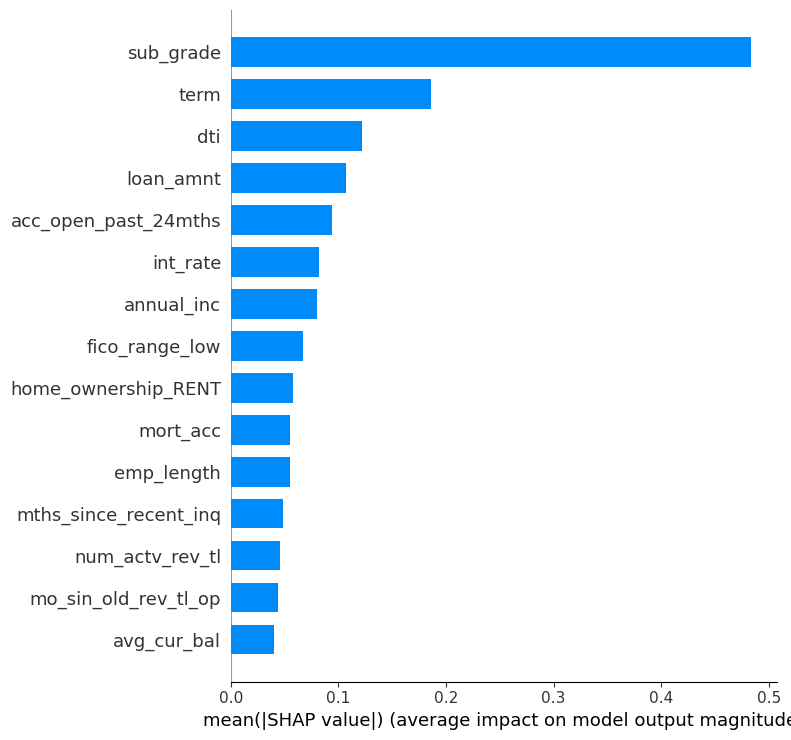

In [69]:
import shap

# SHAP works directly on the XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values on a sample of test set (full set takes too long)
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

# Global feature importance plot
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=15)

In [71]:
# Pick one applicant from test set
applicant_idx = 0
applicant = X_test_sample.iloc[[applicant_idx]]
applicant_shap = shap_values[applicant_idx]

# Get top 3 reasons (highest absolute SHAP values)
shap_series = pd.Series(applicant_shap, index=X_test.columns)
top_reasons = shap_series.abs().sort_values(ascending=False).head(3)

print(f"Credit Score: {test_scores[applicant_idx]}")
print(f"\nTop 3 factors driving this score:")
for feature, shap_val in shap_series[top_reasons.index].items():
    direction = "increased risk ↑" if shap_val > 0 else "decreased risk ↓"
    print(f"  {feature}: {direction} (SHAP: {shap_val:.3f})")

Credit Score: 565

Top 3 factors driving this score:
  loan_amnt: increased risk ↑ (SHAP: 0.250)
  delinq_2yrs: increased risk ↑ (SHAP: 0.230)
  sub_grade: increased risk ↑ (SHAP: 0.195)


In [73]:
# Save SHAP explainer
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Save the scoring function
joblib.dump(probability_to_score, '../models/scoring_function.pkl')

print("All artifacts saved.")

All artifacts saved.


In [75]:
# Save median values for all features
# (used to fill in the 69 features the user doesn't enter)
feature_medians = X_train.median()
feature_medians.to_csv('../models/feature_medians.csv')
print("Feature medians saved.")

Feature medians saved.
